# Binary Experiment — Cytokine vs PBS (Per-Cytokine Binary MIL, Shared Encoder)

For each of the 10 cytokines used in `experiment_subset.ipynb`, trains a dedicated
2-class AB-MIL model (cytokine vs PBS) using a single shared encoder pre-trained
jointly on all 10 cytokines + PBS.

## Why binary models?

Multi-class training forces the model to simultaneously separate 11 conditions.
A cytokine with a weak but real transcriptional signature may not be distinguishable
from 9 other active conditions, but may be cleanly separable from resting cells (PBS)
in a dedicated two-class setting. Binary models answer: *"Is there any learnable signal
at all for this cytokine, independent of competition from other cytokines?"*

## Why a shared encoder?

The encoder is pre-trained on cell-type classification using all 10 cytokines + PBS.
This gives it general, biology-grounded embeddings before any cytokine-specific
signal is introduced. Freezing it for all binary models ensures that per-cytokine
differences reflect attention + classification learning, not encoder specialization.

## Two complementary metrics

For each cytokine, two metrics are computed from the p_correct_trajectory
(probability of the correct cytokine class at each logged epoch), aggregated
to donor level (median across pseudo-tubes per donor, then mean across donors):

1. **Normalized trajectory AUC** — `AUC(p_correct(t) / max(p_correct(t)))`
   Captures the *shape* of learning: how quickly did the model reach its eventual
   performance ceiling? A cytokine that converges quickly gets a higher normalized
   AUC, regardless of absolute probability level.

2. **Final probability** — `p_correct(t_final)`
   Captures whether *actual learning occurred*. Values near 0.5 (chance for binary)
   indicate no detectable signal; values near 1.0 indicate confident classification.

Together: *"How fast?"* (normalized AUC) and *"How much?"* (final probability).

Connect to the cluster kernel before running.
All paths in `configs/default.yaml` point to cluster storage.

In [1]:
import json
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from torch.utils.data import DataLoader

from cytokine_mil.data.dataset import PseudoTubeDataset, CellDataset
from cytokine_mil.training.train_encoder import train_encoder
from cytokine_mil.training.train_mil import train_mil
from cytokine_mil.experiment_setup import (
    build_stage1_manifest,
    filter_manifest,
    make_binary_manifest,
    split_manifest_by_donor,
    build_encoder,
    build_mil_model,
)

In [2]:
with open("cytokines/cytokines-mil/configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = cfg["dynamics"]["random_seeds"][0]

# Lower LR than multi-class: binary task converges faster, needs gentler updates.
BINARY_LR     = 0.001
BINARY_EPOCHS = 60

print(f"Device: {DEVICE}")
print(f"Seed:   {SEED}")
print(f"Binary MIL — LR: {BINARY_LR}  Epochs: {BINARY_EPOCHS}")

Device: cuda
Seed:   42
Binary MIL — LR: 0.001  Epochs: 60


## 1. Data

In [3]:
MANIFEST_PATH = cfg["data"]["manifest_path"]
DATA_DIR      = Path(MANIFEST_PATH).parent

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

with open(str(DATA_DIR / "hvg_list.json")) as f:
    gene_names = json.load(f)

print(f"Full manifest entries: {len(manifest)}")
print(f"HVGs: {len(gene_names)}")

Full manifest entries: 10920
HVGs: 4000


In [4]:
# Same 10-cytokine subset as experiment_subset.ipynb
EASY_CYTOKINES   = ["IL-4", "M-CSF", "IL-10", "TNF-alpha", "IL-2"]
HARD_CYTOKINES   = ["IL-22", "VEGF", "IL-12", "OSM", "HGF"]
SUBSET_CYTOKINES = EASY_CYTOKINES + HARD_CYTOKINES

# D2 and D3: most biologically distinct — never used in optimizer steps
VAL_DONORS = ["Donor2", "Donor3"]

manifest_cytokines = {e["cytokine"] for e in manifest}
missing = [c for c in SUBSET_CYTOKINES if c not in manifest_cytokines]
if missing:
    print(f"WARNING — cytokines not found in manifest: {missing}")
    print(f"Available names (sample): {sorted(manifest_cytokines)[:20]}")
else:
    print("All selected cytokines found in manifest.")
print(f"Subset: {SUBSET_CYTOKINES}")

All selected cytokines found in manifest.
Subset: ['IL-4', 'M-CSF', 'IL-10', 'TNF-alpha', 'IL-2', 'IL-22', 'VEGF', 'IL-12', 'OSM', 'HGF']


In [5]:
# Filter to subset + PBS for Stage 1 encoder pre-training
subset_manifest = filter_manifest(manifest, cytokines=SUBSET_CYTOKINES, include_pbs=True)
print(f"Subset manifest entries: {len(subset_manifest)}")
print(f"Classes: {sorted({e['cytokine'] for e in subset_manifest})}")

# Stage 1 manifest: one tube per cytokine, train donors only
train_subset, _ = split_manifest_by_donor(subset_manifest, val_donors=VAL_DONORS)
STAGE1_MANIFEST_PATH = str(DATA_DIR / "manifest_stage1_binary.json")
build_stage1_manifest(train_subset, save_path=STAGE1_MANIFEST_PATH)

cell_dataset = CellDataset(STAGE1_MANIFEST_PATH, gene_names=gene_names, preload=True)
cell_loader  = DataLoader(cell_dataset, batch_size=256, shuffle=True, num_workers=0)
print(f"\nTrain donors: {sorted({e['donor'] for e in train_subset})}")
print(f"Stage 1 cells: {len(cell_dataset)}")
print(f"Cell types:    {cell_dataset.n_cell_types()}")

Subset manifest entries: 1320
Classes: ['HGF', 'IL-10', 'IL-12', 'IL-2', 'IL-22', 'IL-4', 'M-CSF', 'OSM', 'PBS', 'TNF-alpha', 'VEGF']

Train donors: ['Donor1', 'Donor10', 'Donor11', 'Donor12', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']
Stage 1 cells: 4873
Cell types:    18


## 2. Stage 1 — Joint Encoder Pre-training

Train a single shared encoder on cell-type classification across all 10 cytokines + PBS.
This encoder is then frozen and reused by every per-cytokine binary MIL model.
Sharing the encoder ensures per-cytokine differences reflect attention/classifier
learning only — not encoder specialization.

In [6]:
encoder = build_encoder(
    n_input_genes=len(gene_names),
    n_cell_types=cell_dataset.n_cell_types(),
    embed_dim=cfg["model"]["embedding_dim"],
)

encoder = train_encoder(
    encoder,
    cell_loader,
    n_epochs=10,
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    device=DEVICE,
    verbose=True,
)

torch.save(encoder.state_dict(), "encoder_stage1_binary.pt")
print("\nShared encoder saved.")

[Stage 1] Epoch   1/10 | loss=2.1126 | acc=0.3928


[Stage 1] Epoch   2/10 | loss=0.5062 | acc=0.8225


[Stage 1] Epoch   3/10 | loss=0.3094 | acc=0.8890


[Stage 1] Epoch   4/10 | loss=0.2206 | acc=0.9210


[Stage 1] Epoch   5/10 | loss=0.1578 | acc=0.9466


[Stage 1] Epoch   6/10 | loss=0.1069 | acc=0.9704


[Stage 1] Epoch   7/10 | loss=0.0743 | acc=0.9828


[Stage 1] Epoch   8/10 | loss=0.0452 | acc=0.9928


[Stage 1] Epoch   9/10 | loss=0.0292 | acc=0.9967


[Stage 1] Epoch  10/10 | loss=0.0152 | acc=0.9994

Shared encoder saved.


## 3. Stage 2 — Per-Cytokine Binary MIL Models

For each cytokine, build a 2-class dataset (cytokine vs PBS), split by donor,
and train a fresh attention + classifier on top of the frozen shared encoder.

The encoder weights are identical across all 10 models. The attention module and
bag classifier are trained independently per cytokine.

In [7]:
# --- Metric helper functions ---

def compute_normalized_auc(traj):
    """
    AUC(p_correct(t) / max(p_correct(t))), trapezoid rule / (n-1).

    Maximum possible value is 1.0 (model converges immediately and stays).
    Captures the shape of learning: how quickly did the model reach its ceiling?
    The absolute level of learning is captured separately by final probability.
    """
    arr = np.array(traj, dtype=float)
    max_val = arr.max()
    if max_val < 1e-10:
        return 0.0
    norm = arr / max_val
    return float(np.trapz(norm) / max(len(norm) - 1, 1))


def compute_final_prob(traj):
    """p_correct(t_final). Near 0.5 = no learning (binary); near 1.0 = strong signal."""
    return float(traj[-1]) if len(traj) > 0 else 0.0


def aggregate_binary_metrics(records, target_cytokine):
    """
    Aggregate metrics for target_cytokine tubes to donor level.

    Aggregation: median across tubes per donor, then mean across donors.
    Only cytokine tubes are used (PBS tubes are excluded).

    Returns dict with keys 'norm_auc' and 'final_p'.
    Metric descriptions:
      norm_auc: AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1),
                aggregated to donor level (median per donor, mean across donors)
      final_p:  p_correct(t_final),
                aggregated to donor level (median per donor, mean across donors)
    """
    by_donor = defaultdict(list)
    for r in records:
        if r["cytokine"] == target_cytokine:
            by_donor[r["donor"]].append(r)

    if not by_donor:
        return {"norm_auc": float("nan"), "final_p": float("nan")}

    donor_norm_aucs, donor_final_ps = [], []
    for donor, recs in by_donor.items():
        donor_norm_aucs.append(float(np.median([compute_normalized_auc(r["p_correct_trajectory"]) for r in recs])))
        donor_final_ps.append(float(np.median([compute_final_prob(r["p_correct_trajectory"]) for r in recs])))

    return {
        "norm_auc": float(np.mean(donor_norm_aucs)),
        "final_p":  float(np.mean(donor_final_ps)),
    }

In [8]:
# --- Per-cytokine binary MIL training ---
# Each model: fresh attention + classifier on top of the frozen shared encoder.
# verbose=False to keep output manageable (60 epochs x 10 cytokines).

binary_dynamics = {}  # cyt -> dynamics dict from train_mil

for cyt in SUBSET_CYTOKINES:
    print(f"\n=== {cyt} vs PBS ===")

    bin_manifest, bin_label = make_binary_manifest(subset_manifest, cyt)
    train_bin, val_bin = split_manifest_by_donor(bin_manifest, val_donors=VAL_DONORS)

    # Save manifests to disk (required by PseudoTubeDataset)
    safe_cyt   = cyt.replace("/", "_").replace(" ", "_").replace("-", "_")
    train_path = str(DATA_DIR / f"manifest_binary_{safe_cyt}_train.json")
    val_path   = str(DATA_DIR / f"manifest_binary_{safe_cyt}_val.json")
    with open(train_path, "w") as f:
        json.dump(train_bin, f)
    with open(val_path, "w") as f:
        json.dump(val_bin, f)

    train_ds = PseudoTubeDataset(train_path, bin_label, gene_names=gene_names, preload=True)
    val_ds   = PseudoTubeDataset(val_path,   bin_label, gene_names=gene_names, preload=True)
    print(f"  Train tubes: {len(train_ds)}  Val tubes: {len(val_ds)}")

    # Fresh attention + classifier; shared frozen encoder
    mil = build_mil_model(
        encoder,
        embed_dim=cfg["model"]["embedding_dim"],
        attention_hidden_dim=cfg["model"]["attention_hidden_dim"],
        n_classes=2,
        encoder_frozen=True,
    )

    dyn = train_mil(
        mil, train_ds,
        n_epochs=BINARY_EPOCHS,
        lr=BINARY_LR,
        momentum=cfg["training"]["momentum"],
        lr_scheduler=cfg["training"]["lr_scheduler"],
        lr_warmup_epochs=cfg["training"]["lr_warmup_epochs"],
        log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
        device=DEVICE, seed=SEED, verbose=False,
        val_dataset=val_ds,
    )

    binary_dynamics[cyt] = dyn

    # Quick per-cytokine summary (cytokine tubes only, not PBS)
    train_recs = [r for r in dyn["records"]     if r["cytokine"] == cyt]
    val_recs   = [r for r in dyn["val_records"] if r["cytokine"] == cyt]
    t_p = np.mean([r["p_correct_trajectory"][-1] for r in train_recs]) if train_recs else float("nan")
    v_p = np.mean([r["p_correct_trajectory"][-1] for r in val_recs])   if val_recs   else float("nan")
    print(f"  Done — train P_final={t_p:.3f}  val P_final={v_p:.3f}")

print("\nAll binary models trained.")


=== IL-4 vs PBS ===


Preloading tubes: 100%|████████████████████████| 40/40 [00:05<00:00,  6.79it/s]


  Train tubes: 200  Val tubes: 40


  Done — train P_final=1.000  val P_final=0.865

=== M-CSF vs PBS ===


Preloading tubes: 100%|████████████████████████| 40/40 [00:03<00:00, 12.29it/s]


...

  Train tubes: 200  Val tubes: 40


  Done — train P_final=1.000  val P_final=1.000

=== HGF vs PBS ===


Preloading tubes: 100%|████████████████████████| 40/40 [00:04<00:00,  9.81it/s]


  Train tubes: 200  Val tubes: 40


  Done — train P_final=1.000  val P_final=1.000

All binary models trained.


## 4. Results

In [9]:
# --- Compute both metrics per cytokine ---

metrics = {}
for cyt, dyn in binary_dynamics.items():
    train_m = aggregate_binary_metrics(dyn["records"],     target_cytokine=cyt)
    val_m   = aggregate_binary_metrics(dyn["val_records"], target_cytokine=cyt)
    metrics[cyt] = {
        "train_norm_auc": train_m["norm_auc"],
        "train_final_p":  train_m["final_p"],
        "val_norm_auc":   val_m["norm_auc"],
        "val_final_p":    val_m["final_p"],
    }

# Sort by train normalized AUC descending
ranked = sorted(metrics.items(), key=lambda x: x[1]["train_norm_auc"], reverse=True)

print("Binary experiment — per-cytokine learnability")
print()
print("Metric 1: AUC(p_correct(t) / max(p_correct(t))), trapezoid rule / (n_epochs-1),")
print("          aggregated to donor level (median per donor, mean across donors).")
print("          Shape of learning: how quickly did the model reach its ceiling?")
print()
print("Metric 2: p_correct(t_final),")
print("          aggregated to donor level (median per donor, mean across donors).")
print("          Signal strength. Values near 0.5 = chance (binary).")
print()
print(f"{'Rank':>4}  {'Cytokine':<14}  {'NormAUC(T)':>10}  {'NormAUC(V)':>10}  {'FinalP(T)':>9}  {'FinalP(V)':>9}  Group")
print("-" * 72)
for rank, (cyt, m) in enumerate(ranked, 1):
    group = "EASY" if cyt in EASY_CYTOKINES else "HARD"
    print(f"  {rank:2d}.  {cyt:<14}  "
          f"{m['train_norm_auc']:>10.3f}  {m['val_norm_auc']:>10.3f}  "
          f"{m['train_final_p']:>9.3f}  {m['val_final_p']:>9.3f}  {group}")

top5 = [c for c, _ in ranked[:5]]
bot5 = [c for c, _ in ranked[-5:]]
print()
print(f"Pre-registered check: easy in top-5: {sum(c in EASY_CYTOKINES for c in top5)}/5  "
      f"hard in bot-5: {sum(c in HARD_CYTOKINES for c in bot5)}/5")

Binary experiment — per-cytokine learnability

Metric 1: AUC(p_correct(t) / max(p_correct(t))), trapezoid rule / (n_epochs-1),
          aggregated to donor level (median per donor, mean across donors).
          Shape of learning: how quickly did the model reach its ceiling?

Metric 2: p_correct(t_final),
          aggregated to donor level (median per donor, mean across donors).
          Signal strength. Values near 0.5 = chance (binary).

Rank  Cytokine        NormAUC(T)  NormAUC(V)  FinalP(T)  FinalP(V)  Group
------------------------------------------------------------------------
   1.  M-CSF                0.995       1.000      1.000      1.000  EASY
   2.  IL-4                 0.994       0.976      1.000      0.969  EASY
   3.  IL-2                 0.994       0.999      1.000      1.000  EASY
   4.  HGF                  0.993       1.000      1.000      1.000  HARD
   5.  VEGF                 0.992       1.000      1.000      1.000  HARD
   6.  IL-10                0.991   

/tmp/ipykernel_3755215/381158277.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(norm) / max(len(norm) - 1, 1))


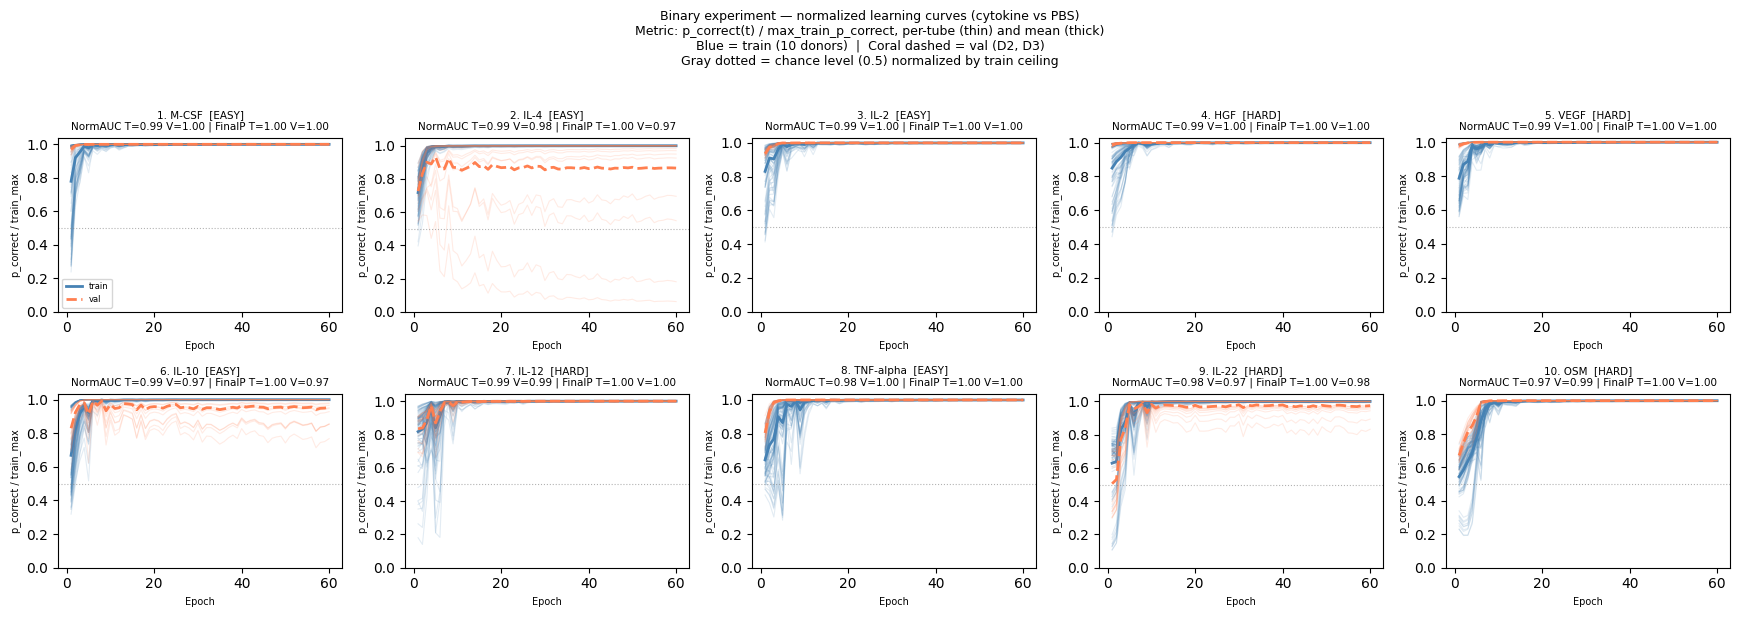

In [10]:
# --- Normalized learning curves per cytokine ---
# Each panel: p_correct normalized by the train ceiling of that cytokine.
# Blue thin/thick = individual tubes / mean (train). Coral dashed = val mean.
# Panels sorted by train normalized AUC (highest = fastest learner, top-left).

n_cols = 5
n_rows = (len(SUBSET_CYTOKINES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax_idx, (cyt, _) in enumerate(ranked):
    ax  = axes[ax_idx]
    dyn = binary_dynamics[cyt]
    epochs = dyn["logged_epochs"]

    train_cyt = [r for r in dyn["records"]     if r["cytokine"] == cyt]
    val_cyt   = [r for r in dyn["val_records"] if r["cytokine"] == cyt]

    all_train_vals = np.concatenate([r["p_correct_trajectory"] for r in train_cyt]) if train_cyt else np.array([1.0])
    train_ceil = max(float(all_train_vals.max()), 1e-10)

    if train_cyt:
        train_mat = np.array([r["p_correct_trajectory"] for r in train_cyt]) / train_ceil
        for row in train_mat:
            ax.plot(epochs, row, color="steelblue", alpha=0.15, linewidth=0.8)
        ax.plot(epochs, train_mat.mean(axis=0), color="steelblue", linewidth=2.0, label="train")

    if val_cyt:
        val_mat = np.array([r["p_correct_trajectory"] for r in val_cyt]) / train_ceil
        for row in val_mat:
            ax.plot(epochs, row, color="coral", alpha=0.15, linewidth=0.8)
        ax.plot(epochs, val_mat.mean(axis=0), color="coral", linewidth=2.0,
                linestyle="--", label="val")

    m     = metrics[cyt]
    group = "EASY" if cyt in EASY_CYTOKINES else "HARD"
    rank  = next(i + 1 for i, (c, _) in enumerate(ranked) if c == cyt)
    ax.set_title(
        f"{rank}. {cyt}  [{group}]\n"
        f"NormAUC T={m['train_norm_auc']:.2f} V={m['val_norm_auc']:.2f} | "
        f"FinalP T={m['train_final_p']:.2f} V={m['val_final_p']:.2f}",
        fontsize=7.5,
    )
    ax.set_xlabel("Epoch", fontsize=7)
    ax.set_ylabel("p_correct / train_max", fontsize=7)
    ax.axhline(0.5 / train_ceil, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_ylim(bottom=0)
    if ax_idx == 0:
        ax.legend(fontsize=6)

for ax in axes[len(SUBSET_CYTOKINES):]:
    ax.set_visible(False)

plt.suptitle(
    "Binary experiment — normalized learning curves (cytokine vs PBS)\n"
    "Metric: p_correct(t) / max_train_p_correct, per-tube (thin) and mean (thick)\n"
    "Blue = train (10 donors)  |  Coral dashed = val (D2, D3)\n"
    "Gray dotted = chance level (0.5) normalized by train ceiling",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig("binary_normalized_curves.png", dpi=150, bbox_inches="tight")
plt.show()

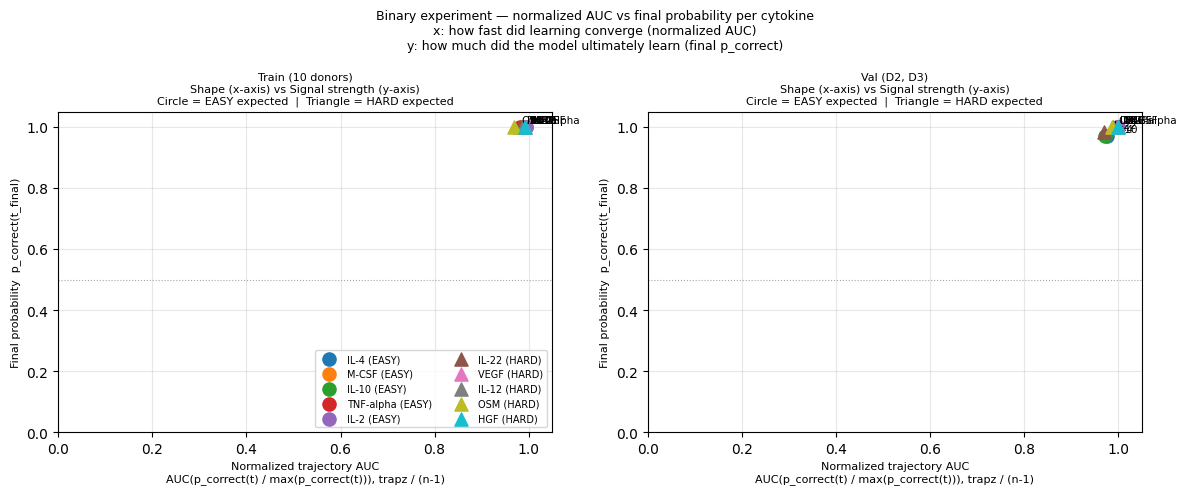

In [11]:
# --- Scatter: normalized AUC vs final probability ---
# Left = train donors, right = val donors (D2, D3).
# Circle = EASY expected, Triangle = HARD expected.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10.colors

for split_idx, (split_label, auc_key, fp_key) in enumerate([
    ("Train (10 donors)", "train_norm_auc", "train_final_p"),
    ("Val (D2, D3)",      "val_norm_auc",   "val_final_p"),
]):
    ax = axes[split_idx]
    for ci, cyt in enumerate(SUBSET_CYTOKINES):
        m      = metrics[cyt]
        color  = colors[ci % len(colors)]
        marker = "o" if cyt in EASY_CYTOKINES else "^"
        ax.scatter(m[auc_key], m[fp_key], color=color, marker=marker, s=90, zorder=3,
                   label=f"{cyt} ({'EASY' if cyt in EASY_CYTOKINES else 'HARD'})")
        ax.annotate(cyt, (m[auc_key], m[fp_key]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7.5)

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.set_xlabel(
        "Normalized trajectory AUC\n"
        "AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1)",
        fontsize=8,
    )
    ax.set_ylabel("Final probability  p_correct(t_final)", fontsize=8)
    ax.set_title(
        f"{split_label}\nShape (x-axis) vs Signal strength (y-axis)\n"
        "Circle = EASY expected  |  Triangle = HARD expected",
        fontsize=8,
    )
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc="lower right", ncol=2)
plt.suptitle(
    "Binary experiment — normalized AUC vs final probability per cytokine\n"
    "x: how fast did learning converge (normalized AUC)\n"
    "y: how much did the model ultimately learn (final p_correct)",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("binary_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

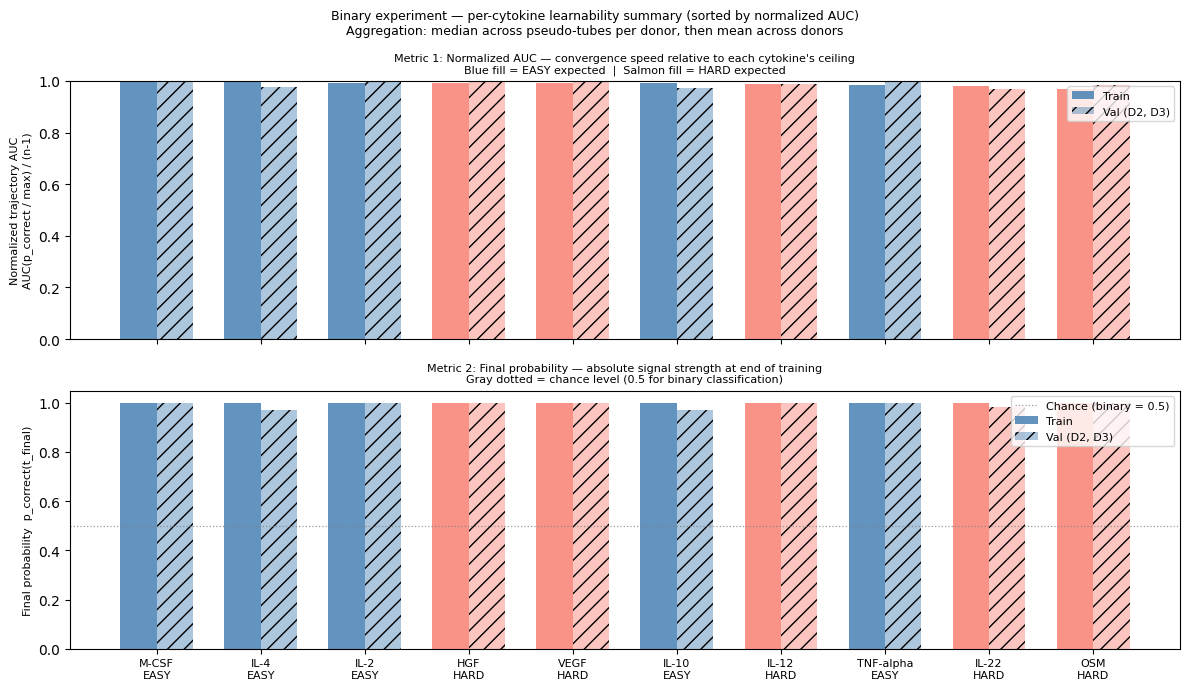

In [12]:
# --- Summary bar chart: both metrics side by side, sorted by normalized AUC ---

cyt_order  = [c for c, _ in ranked]
x          = np.arange(len(cyt_order))
bar_width  = 0.35
bar_colors = ["steelblue" if c in EASY_CYTOKINES else "salmon" for c in cyt_order]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: Normalized AUC
ax = axes[0]
ax.bar(x - bar_width / 2, [metrics[c]["train_norm_auc"] for c in cyt_order],
       bar_width, label="Train", color=bar_colors, alpha=0.85)
ax.bar(x + bar_width / 2, [metrics[c]["val_norm_auc"] for c in cyt_order],
       bar_width, label="Val (D2, D3)", color=bar_colors, alpha=0.45, hatch="//")
ax.set_ylabel("Normalized trajectory AUC\nAUC(p_correct / max) / (n-1)", fontsize=8)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
ax.set_title(
    "Metric 1: Normalized AUC — convergence speed relative to each cytokine's ceiling\n"
    "Blue fill = EASY expected  |  Salmon fill = HARD expected",
    fontsize=8,
)

# Bottom panel: Final probability
ax = axes[1]
ax.bar(x - bar_width / 2, [metrics[c]["train_final_p"] for c in cyt_order],
       bar_width, label="Train", color=bar_colors, alpha=0.85)
ax.bar(x + bar_width / 2, [metrics[c]["val_final_p"] for c in cyt_order],
       bar_width, label="Val (D2, D3)", color=bar_colors, alpha=0.45, hatch="//")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.9, alpha=0.8,
           label="Chance (binary = 0.5)")
ax.set_ylabel("Final probability  p_correct(t_final)", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n{'EASY' if c in EASY_CYTOKINES else 'HARD'}" for c in cyt_order],
    fontsize=8,
)
ax.legend(fontsize=8)
ax.set_title(
    "Metric 2: Final probability — absolute signal strength at end of training\n"
    "Gray dotted = chance level (0.5 for binary classification)",
    fontsize=8,
)

plt.suptitle(
    "Binary experiment — per-cytokine learnability summary (sorted by normalized AUC)\n"
    "Aggregation: median across pseudo-tubes per donor, then mean across donors",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("binary_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()